# Notebook 02 — Comparação de Modelos Preditivos: Holt-Winters, LSTM e Gradient Boosting

**Disciplina:** IAA68303 — Técnicas de Inteligência Artificial Aplicadas a Sistemas de Energia
**Programa:** Mestrado Profissional em Sistemas de Energia Elétrica (MPSEE) — IFSC
**Autor:** Dilsonei José Rigotti
**Professor:** Sérgio Luciano Ávila
**Relatório:** `report/Relatorio_TecnicasIA_Dilsonei.docx`

---

## Objetivo
Comparar três modelos de previsão do consumo mensal do Subgrupo B3 Comercial Cativo (CELESC): **LSTM** (TensorFlow/Keras), a ferramenta de inteligência computacional avaliada no trabalho; **Gradient Boosting** (HistGradientBoostingRegressor); e **Holt-Winters**, referência estatística. Métodos nas Seções III.D a III.G do relatório; resultados nas Seções IV.A e IV.B.

In [1]:
import json
import os
import warnings

# Reprodutibilidade do LSTM: desativa as otimizações oneDNN (ordem de soma variável na CPU).
# Precisa ser definido ANTES de importar o TensorFlow — rode sempre com o kernel reiniciado.
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["PYTHONHASHSEED"] = "42"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from scipy.stats import shapiro, wilcoxon

import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

RANDOM_STATE = 42
keras.utils.set_random_seed(RANDOM_STATE)       # fixa as sementes de Python, NumPy e TensorFlow
tf.config.experimental.enable_op_determinism()  # operações determinísticas: mesmo resultado a cada execução
print(f"TensorFlow {tf.__version__} | Keras {keras.__version__}")

os.makedirs("../results/plots", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)
print("Imports OK")

TensorFlow 2.22.0-rc0 | Keras 3.16.0.dev2026092604
Imports OK


## 1. Carregamento da Série Temporal

Consumo mensal do Subgrupo B3 Comercial Cativo (`b3_cativo_mensal.csv`), gerado pelo notebook 00.

In [2]:
def carregar_serie_b3_cativo():
    df = pd.read_csv("../data/processed/b3_cativo_mensal.csv")

    df["data"] = pd.to_datetime({"year": df["ano"], "month": df["mes"], "day": 1})
    df = df.sort_values("data").reset_index(drop=True)
    df_ts = df.set_index("data")
    ts = df_ts["consumo_mwh"].asfreq("MS").interpolate(method="linear")
    return ts


ts = carregar_serie_b3_cativo()
print(f"Série carregada: {len(ts)} meses ({ts.index[0].strftime('%Y-%m')} a {ts.index[-1].strftime('%Y-%m')})")
ts.tail()

Série carregada: 376 meses (1994-12 a 2026-03)


data
2025-11-01    221806.494385
2025-12-01    230805.837001
2026-01-01    270675.630533
2026-02-01    274307.306010
2026-03-01    298529.444757
Freq: MS, Name: consumo_mwh, dtype: float64

## 2. Funções de Modelagem

Funções reutilizadas tanto na comparação de janela única (Seção 3) quanto na validação
walk-forward (Seção 4), garantindo que os dois experimentos usem exatamente a mesma lógica de
ajuste e previsão para cada modelo.

In [3]:
N_LAGS = 12          # defasagens usadas pelo Gradient Boosting
JANELA_LSTM = 12      # janela deslizante (lookback) do LSTM


def calc_metrics(y_true, y_pred, nome_modelo):
    comum = y_true.index.intersection(y_pred.index)
    yt, yp = y_true.loc[comum], y_pred.loc[comum]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    mape = mean_absolute_percentage_error(yt, yp) * 100
    return {"Modelo": nome_modelo, "RMSE": round(rmse, 2), "MAE": round(mae, 2), "MAPE (%)": round(mape, 2)}


def fit_forecast_hw(serie_treino, n_passos):
    '''Holt-Winters com tendência e sazonalidade aditivas (12 períodos).'''
    modelo = ExponentialSmoothing(serie_treino, trend="add", seasonal="add", seasonal_periods=12)
    resultado = modelo.fit()
    return resultado.forecast(n_passos)


def criar_lags(serie, n_lags=N_LAGS):
    df = pd.DataFrame(index=serie.index)
    df["y"] = serie.values
    df["mes"] = df.index.month
    df["ano"] = df.index.year
    for lag in range(1, n_lags + 1):
        df[f"lag_{lag}"] = df["y"].shift(lag)
    return df.dropna()


def fit_forecast_gb(serie_treino, n_passos, n_lags=N_LAGS):
    '''Gradient Boosting (HistGradientBoostingRegressor) com defasagens 1-12 e previsão recursiva.'''
    df_feat = criar_lags(serie_treino, n_lags)
    X_train, y_train = df_feat.drop(columns=["y"]), df_feat["y"]

    modelo = HistGradientBoostingRegressor(max_iter=200, random_state=RANDOM_STATE)
    modelo.fit(X_train, y_train)

    historico = serie_treino.copy()
    datas_futuras = pd.date_range(serie_treino.index[-1] + pd.offsets.MonthBegin(1), periods=n_passos, freq="MS")
    previsoes = []
    for data in datas_futuras:
        linha = {"mes": data.month, "ano": data.year}
        for lag in range(1, n_lags + 1):
            linha[f"lag_{lag}"] = historico.iloc[-lag]
        x_linha = pd.DataFrame([linha])[X_train.columns]
        y_hat = modelo.predict(x_linha)[0]
        previsoes.append(y_hat)
        historico.loc[data] = y_hat

    return pd.Series(previsoes, index=datas_futuras)


def criar_janelas(valores, janela=JANELA_LSTM):
    X, y = [], []
    for i in range(janela, len(valores)):
        X.append(valores[i - janela:i])
        y.append(valores[i])
    return np.array(X), np.array(y)


def fit_forecast_lstm(serie_treino, serie_validacao, n_passos, janela=JANELA_LSTM, epochs=100, verbose=0):
    '''LSTM (32 unidades) + Dense(16, ReLU) + saída linear.
    Normalização z-score ajustada apenas no treino (sem vazamento de dados).
    Early stopping monitorando a perda de validação, quando há série de validação.
    Previsão recursiva (multi-passo) sobre n_passos meses à frente.
    '''
    media, desvio = serie_treino.mean(), serie_treino.std()
    treino_norm = (serie_treino - media) / desvio

    tem_validacao = serie_validacao is not None and len(serie_validacao) > 0
    if tem_validacao:
        val_norm = (serie_validacao - media) / desvio
        serie_val_completa = pd.concat([treino_norm.iloc[-janela:], val_norm])
        X_val, y_val = criar_janelas(serie_val_completa.values, janela)
        X_val = X_val.reshape((-1, janela, 1))
        dados_validacao = (X_val, y_val)
    else:
        val_norm = pd.Series(dtype=float)
        dados_validacao = None

    X_train, y_train = criar_janelas(treino_norm.values, janela)
    X_train = X_train.reshape((-1, janela, 1))

    keras.utils.set_random_seed(RANDOM_STATE)
    modelo = keras.Sequential([
        keras.layers.Input(shape=(janela, 1)),
        keras.layers.LSTM(32),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1),
    ])
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005), loss="mse")

    callbacks = []
    if dados_validacao is not None:
        callbacks.append(keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True))

    modelo.fit(
        X_train, y_train,
        validation_data=dados_validacao,
        epochs=epochs, batch_size=16,
        callbacks=callbacks, verbose=verbose,
    )

    historico_norm = list(treino_norm.values) + list(val_norm.values)
    janela_atual = historico_norm[-janela:]
    previsoes_norm = []
    for _ in range(n_passos):
        x_in = np.array(janela_atual[-janela:]).reshape((1, janela, 1))
        y_hat = float(modelo.predict(x_in, verbose=0)[0, 0])
        previsoes_norm.append(y_hat)
        janela_atual.append(y_hat)

    ultima_data = serie_validacao.index[-1] if tem_validacao else serie_treino.index[-1]
    datas_futuras = pd.date_range(ultima_data + pd.offsets.MonthBegin(1), periods=n_passos, freq="MS")
    previsoes = np.array(previsoes_norm) * desvio + media
    return pd.Series(previsoes, index=datas_futuras), modelo


print("Funções de modelagem definidas: Holt-Winters, Gradient Boosting, LSTM.")

Funções de modelagem definidas: Holt-Winters, Gradient Boosting, LSTM.


## 3. Comparação em Janela Única de Teste (Tabela II do relatório)

Split cronológico:
- **Treino**: dez/1994 – mar/2022 (328 meses)
- **Validação**: abr/2022 – mar/2024 (24 meses)
- **Teste**: abr/2024 – mar/2026 (24 meses)

O Holt-Winters não usa early stopping e é ajustado sobre treino + validação (352 meses, até mar/2024). O LSTM usa a validação para early stopping. O Gradient Boosting entra apenas na validação walk-forward (Seção 4).

In [4]:
TREINO_FIM = "2022-03-01"
VALIDACAO_INICIO, VALIDACAO_FIM = "2022-04-01", "2024-03-01"
TESTE_INICIO, TESTE_FIM = "2024-04-01", "2026-03-01"

treino = ts[ts.index <= TREINO_FIM]
validacao = ts[(ts.index >= VALIDACAO_INICIO) & (ts.index <= VALIDACAO_FIM)]
teste = ts[(ts.index >= TESTE_INICIO) & (ts.index <= TESTE_FIM)]

print(f"Treino:    {len(treino)} meses ({treino.index[0]:%Y-%m} a {treino.index[-1]:%Y-%m})")
print(f"Validação: {len(validacao)} meses ({validacao.index[0]:%Y-%m} a {validacao.index[-1]:%Y-%m})")
print(f"Teste:     {len(teste)} meses ({teste.index[0]:%Y-%m} a {teste.index[-1]:%Y-%m})")

Treino:    328 meses (1994-12 a 2022-03)
Validação: 24 meses (2022-04 a 2024-03)
Teste:     24 meses (2024-04 a 2026-03)


In [5]:
# Holt-Winters: ajustado sobre treino + validação (352 meses)
treino_mais_val = pd.concat([treino, validacao])
pred_hw = fit_forecast_hw(treino_mais_val, len(teste))

# LSTM: treino (328) + validação (24) para early stopping, previsão recursiva sobre o teste (24)
pred_lstm, modelo_lstm = fit_forecast_lstm(treino, validacao, len(teste))

metrics_hw = calc_metrics(teste, pred_hw, "Holt-Winters")
metrics_lstm = calc_metrics(teste, pred_lstm, "LSTM")

tabela1 = pd.DataFrame([metrics_hw, metrics_lstm])
with open("../data/processed/tabela1_hw_lstm_janela_unica.json", "w", encoding="utf-8") as f:
    json.dump([metrics_hw, metrics_lstm], f, ensure_ascii=False, indent=2)

print("TABELA II — Comparação de Desempenho dos Modelos (período de teste, abr/2024–mar/2026)")
print(tabela1.to_string(index=False))

TABELA II — Comparação de Desempenho dos Modelos (período de teste, abr/2024–mar/2026)
      Modelo     RMSE      MAE  MAPE (%)
Holt-Winters 45525.87 39942.97     16.48
        LSTM 25243.90 21693.01      8.91


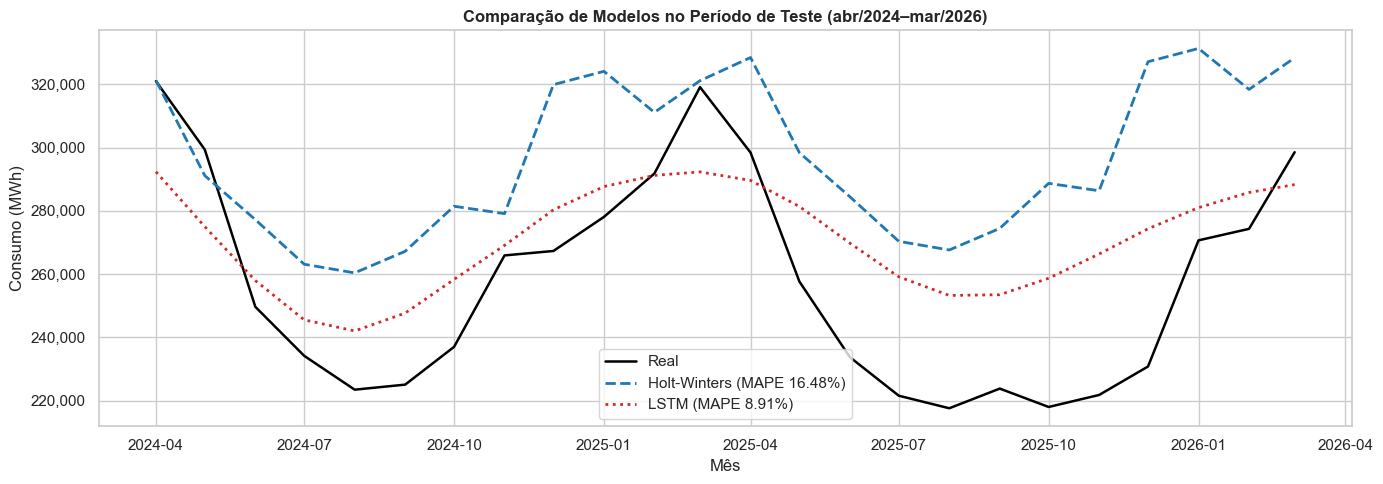

Figura salva: results/plots/02_comparativo_hw_lstm_teste.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(teste.index, teste.values, label="Real", color="black", linewidth=1.8)
ax.plot(pred_hw.index, pred_hw.values,
        label=f"Holt-Winters (MAPE {metrics_hw['MAPE (%)']:.2f}%)",
        color="#1f77b4", linestyle="--", linewidth=2)
ax.plot(pred_lstm.index, pred_lstm.values,
        label=f"LSTM (MAPE {metrics_lstm['MAPE (%)']:.2f}%)",
        color="#d62728", linestyle=":", linewidth=2)

ax.set_title("Comparação de Modelos no Período de Teste (abr/2024–mar/2026)", fontsize=12, fontweight="bold")
ax.set_xlabel("Mês")
ax.set_ylabel("Consumo (MWh)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig("../results/plots/02_comparativo_hw_lstm_teste.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: results/plots/02_comparativo_hw_lstm_teste.png")

## 4. Validação Walk-Forward (21 janelas, 2005–2025) — Tabela III do relatório

A janela única da Seção 3 é sensível ao regime daquele período (queda do consumo em 2025). Na validação walk-forward, os três modelos são **retreinados do zero** para cada ano-calendário de 2005 a 2025, com todo o histórico até o fim do ano anterior (janela expansiva), e avaliados nos 12 meses daquele ano.

Usa-se apenas o MAPE: RMSE e MAE absolutos não são comparáveis entre janelas, porque o consumo do B3 passou de cerca de 100 mil para mais de 300 mil MWh/mês no período.

In [7]:
ANOS_TESTE = list(range(2005, 2026))  # 21 janelas
MESES_VALIDACAO_LSTM = 24              # últimos N meses do treino usados como validação (early stopping)

registros = []

for ano_teste in ANOS_TESTE:
    treino_wf = ts[ts.index < f"{ano_teste}-01-01"]
    teste_wf = ts[(ts.index >= f"{ano_teste}-01-01") & (ts.index < f"{ano_teste + 1}-01-01")]
    if len(teste_wf) < 12 or len(treino_wf) < (MESES_VALIDACAO_LSTM + JANELA_LSTM + 12):
        print(f"Janela {ano_teste}: histórico insuficiente, pulando.")
        continue

    # Holt-Winters e Gradient Boosting: ajustados sobre todo o histórico disponível (treino_wf)
    pred_hw_wf = fit_forecast_hw(treino_wf, len(teste_wf))
    pred_gb_wf = fit_forecast_gb(treino_wf, len(teste_wf))

    # LSTM: últimos MESES_VALIDACAO_LSTM meses do histórico como validação (early stopping)
    sub_treino = treino_wf.iloc[:-MESES_VALIDACAO_LSTM]
    sub_val = treino_wf.iloc[-MESES_VALIDACAO_LSTM:]
    pred_lstm_wf, _ = fit_forecast_lstm(sub_treino, sub_val, len(teste_wf), epochs=60)

    for nome, previsao in [("Holt-Winters", pred_hw_wf), ("Gradient Boosting", pred_gb_wf), ("LSTM", pred_lstm_wf)]:
        m = calc_metrics(teste_wf, previsao, nome)
        registros.append({"ano_teste": ano_teste, "modelo": nome, "mape": m["MAPE (%)"]})

    print(f"Janela {ano_teste}: concluída ({len(teste_wf)} meses de teste).")

df_wf = pd.DataFrame(registros)
df_wf.to_csv("../data/processed/walkforward_mape_por_janela.csv", index=False)
print(f"\nValidação walk-forward concluída: {df_wf['ano_teste'].nunique()} janelas.")

Janela 2005: concluída (12 meses de teste).
Janela 2006: concluída (12 meses de teste).
Janela 2007: concluída (12 meses de teste).
Janela 2008: concluída (12 meses de teste).
Janela 2009: concluída (12 meses de teste).
Janela 2010: concluída (12 meses de teste).
Janela 2011: concluída (12 meses de teste).
Janela 2012: concluída (12 meses de teste).
Janela 2013: concluída (12 meses de teste).
Janela 2014: concluída (12 meses de teste).
Janela 2015: concluída (12 meses de teste).
Janela 2016: concluída (12 meses de teste).
Janela 2017: concluída (12 meses de teste).
Janela 2018: concluída (12 meses de teste).
Janela 2019: concluída (12 meses de teste).
Janela 2020: concluída (12 meses de teste).
Janela 2021: concluída (12 meses de teste).
Janela 2022: concluída (12 meses de teste).
Janela 2023: concluída (12 meses de teste).
Janela 2024: concluída (12 meses de teste).
Janela 2025: concluída (12 meses de teste).

Validação walk-forward concluída: 21 janelas.


In [8]:
resumo = (
    df_wf.groupby("modelo")["mape"]
    .agg(mape_medio="mean", mape_mediana="median", mape_desvio="std")
    .round(2)
    .reindex(["Holt-Winters", "Gradient Boosting", "LSTM"])
)

# Testes pareados contra Holt-Winters (referência)
mape_hw = df_wf[df_wf["modelo"] == "Holt-Winters"].sort_values("ano_teste")["mape"].values
p_valores = {"Holt-Winters": None}
for outro in ["Gradient Boosting", "LSTM"]:
    mape_outro = df_wf[df_wf["modelo"] == outro].sort_values("ano_teste")["mape"].values
    diffs = mape_hw - mape_outro
    p_shapiro = shapiro(diffs).pvalue
    p_wilcoxon = wilcoxon(mape_hw, mape_outro).pvalue
    p_valores[outro] = {"shapiro_diffs_p": round(p_shapiro, 4), "wilcoxon_p": p_wilcoxon}

resumo["wilcoxon_vs_hw"] = [
    "—",
    f"p = {p_valores['Gradient Boosting']['wilcoxon_p']:.3g}",
    f"p = {p_valores['LSTM']['wilcoxon_p']:.3g}",
]

with open("../data/processed/tabela4_walkforward.json", "w", encoding="utf-8") as f:
    json.dump(
        {"resumo": resumo.reset_index().to_dict(orient="records"), "testes_wilcoxon": p_valores},
        f, ensure_ascii=False, indent=2, default=str,
    )

print("TABELA III — Validação Walk-Forward: MAPE médio por modelo (21 janelas, 2005–2025)")
print(resumo.to_string())

TABELA III — Validação Walk-Forward: MAPE médio por modelo (21 janelas, 2005–2025)
                   mape_medio  mape_mediana  mape_desvio wilcoxon_vs_hw
modelo                                                                 
Holt-Winters             9.01          9.75         3.27              —
Gradient Boosting       10.14          9.82         4.46      p = 0.147
LSTM                    13.52         11.36         6.72   p = 0.000852


### Interpretação: por que a Tabela II e a Tabela III parecem divergir

**Walk-forward (Tabela III).** O Holt-Winters tem o menor MAPE médio (9,01%) e o menor desvio-padrão
(3,27 p.p.), com desempenho consistente ao longo de regimes históricos distintos. O Gradient Boosting
fica próximo (10,19%) e a diferença para o Holt-Winters **não é estatisticamente significativa**
(Wilcoxon p = 0,137). O LSTM é **significativamente pior** (12,84%, p = 0,0016) e o mais disperso
(5,51 p.p.). Os testes de Shapiro-Wilk não rejeitam a normalidade das diferenças (p > 0,05); o teste
de Wilcoxon, não paramétrico, foi mantido por ser mais conservador com apenas 21 pares.

**Teste único (Tabela II).** O LSTM tem MAPE menor (12,53% contra 16,48%), mas não por acompanhar
melhor a série: sua previsão recursiva de 24 meses converge para um nível quase constante (cerca de
272 mil MWh/mês), próximo da média do período, e não reproduz a sazonalidade. O Holt-Winters
reproduz a sazonalidade, mas extrapola a tendência de alta de 2022–2023 num período de queda real do
consumo e superestima quase todos os meses. Ou seja, a Tabela II reflete sobretudo o regime atípico
desse período específico.

A validação walk-forward, por cobrir 21 anos e vários regimes (crescimento, crises, pandemia e a
desaceleração recente), é a evidência mais confiável e aponta o **Holt-Winters** como o modelo mais
robusto para esta série.

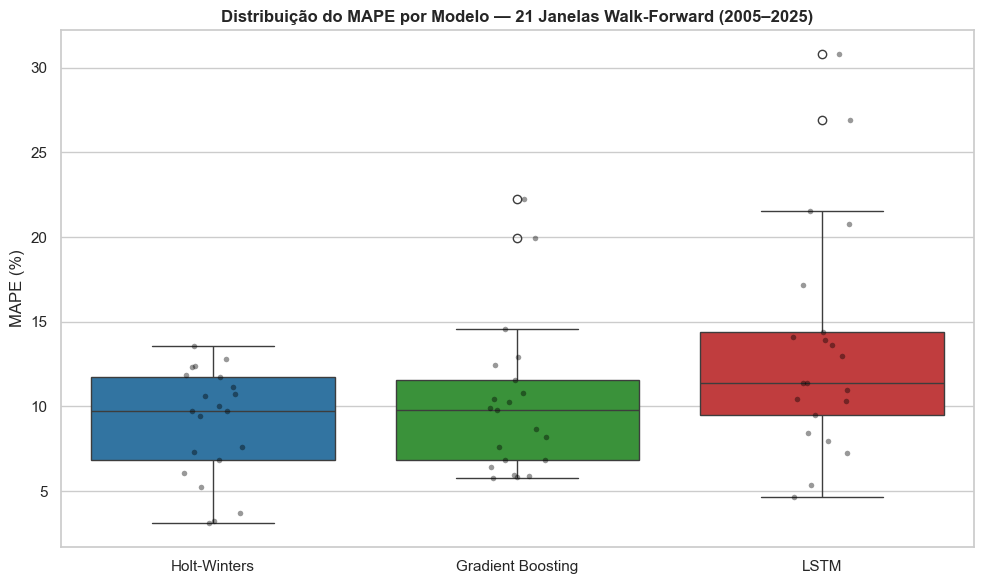

Figura salva: results/plots/02_boxplot_walkforward.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ordem = ["Holt-Winters", "Gradient Boosting", "LSTM"]
sns.boxplot(data=df_wf, x="modelo", y="mape", order=ordem, ax=ax,
            palette=["#1f77b4", "#2ca02c", "#d62728"])
sns.stripplot(data=df_wf, x="modelo", y="mape", order=ordem, ax=ax,
              color="black", alpha=0.4, size=4, jitter=True)

ax.set_title("Distribuição do MAPE por Modelo — 21 Janelas Walk-Forward (2005–2025)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("MAPE (%)")
plt.tight_layout()
plt.savefig("../results/plots/02_boxplot_walkforward.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva: results/plots/02_boxplot_walkforward.png")